In [1]:
from google.colab import drive
drive.mount('/content/drive')

zip_file_path = "/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 4/Devnagari Digits.zip"
extract_path = "/content/"

# Unzip the file silently (-q) to the specified extraction path (-d)
!unzip -q "{zip_file_path}" -d "{extract_path}"

print(f"Successfully extracted '{zip_file_path}' to '{extract_path}'.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully extracted '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Week 4/Devnagari Digits.zip' to '/content/'.


In [3]:
import os
import numpy as np
from PIL import Image

def one_hot_encode(labels, num_classes):
    return np.eye(num_classes)[labels]

In [4]:
def load_dataset(folder_path, img_size=(28, 28)):
    images = []
    labels = []
    class_names = []

    # Sort classes to keep label order consistent
    classes = sorted(os.listdir(folder_path))

    for label, class_name in enumerate(classes):
        class_path = os.path.join(folder_path, class_name)

        if os.path.isdir(class_path):
            class_names.append(class_name)

            for file in os.listdir(class_path):
                img_path = os.path.join(class_path, file)

                try:
                    # Load image using PIL
                    img = Image.open(img_path).convert("RGB")

                    # Resize image
                    img = img.resize(img_size)

                    # Convert to numpy & normalize (0–1)
                    img_array = np.array(img) / 255.0

                    images.append(img_array)
                    labels.append(label)

                except:
                    continue  # skip bad files

    return np.array(images), np.array(labels), class_names

In [5]:
train_path = "/content/DevanagariHandwrittenDigitDataset/Train"

X_train, y_train, class_names = load_dataset(train_path)

# One-hot encode labels
y_train_encoded = one_hot_encode(y_train, len(class_names))

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train_encoded.shape)
print("Classes:", class_names)

X_train shape: (17000, 28, 28, 3)
y_train shape: (17000, 10)
Classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']


In [6]:
test_path = "/content/DevanagariHandwrittenDigitDataset/Train"

X_test, y_test, _ = load_dataset(test_path)

y_test_encoded = one_hot_encode(y_test, len(class_names))

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test_encoded.shape)

X_test shape: (17000, 28, 28, 3)
y_test shape: (17000, 10)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model = Sequential([
    Flatten(input_shape=(28, 28, 3)),

    Dense(64, activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),

    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       150,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 194,506 (759.79 KB)

 Trainable params: 194,506 (759.79 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # because of one-hot encoding
    metrics=['accuracy']
)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True
)

history = model.fit(
    X_train,
    y_train_encoded,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3390 - loss: 1.9660

107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5551 - loss: 1.5473 - val_accuracy: 0.0000e+00 - val_loss: 6.7091
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8728 - loss: 0.4283 - val_accuracy: 0.0000e+00 - val_loss: 8.0022
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9422 - loss: 0.2197 - val_accuracy: 0.0000e+00 - val_loss: 8.6078
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9632 - loss: 0.1407 - val_accuracy: 0.0000e+00 - val_loss: 9.1539


In [10]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_encoded)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

532/532 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6554 - loss: 1.8987
Test Loss: 1.898740291595459
Test Accuracy: 0.6553529500961304


In [11]:
model.save("final_model.h5")

In [12]:
from tensorflow.keras.models import load_model

loaded_model = load_model("final_model.h5")

In [13]:
loss, acc = loaded_model.evaluate(X_test, y_test_encoded)

print("Loaded Model Accuracy:", acc)

532/532 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6554 - loss: 1.8987
Loaded Model Accuracy: 0.6553529500961304


In [14]:
predictions = loaded_model.predict(X_test)

532/532 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [15]:
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test_encoded, axis=1)

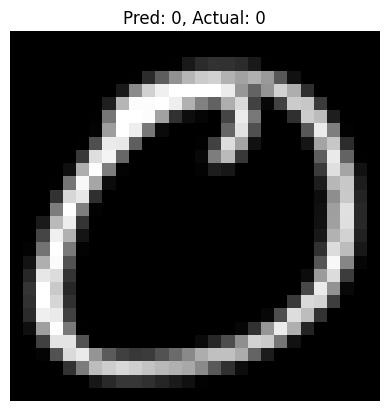

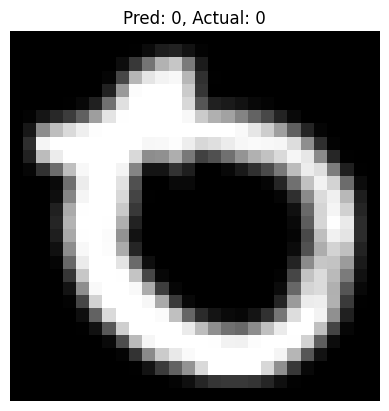

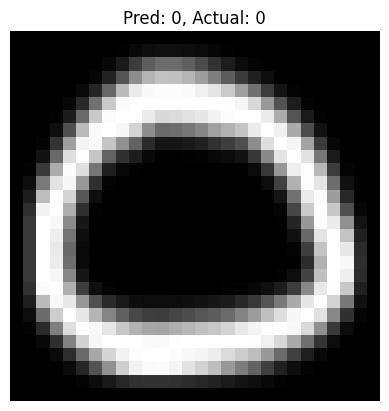

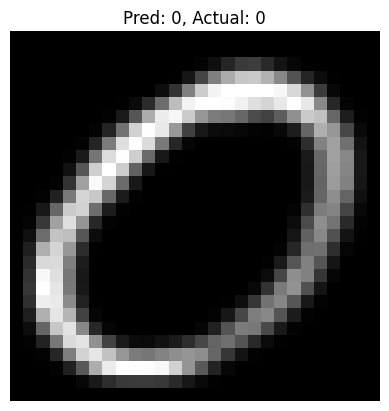

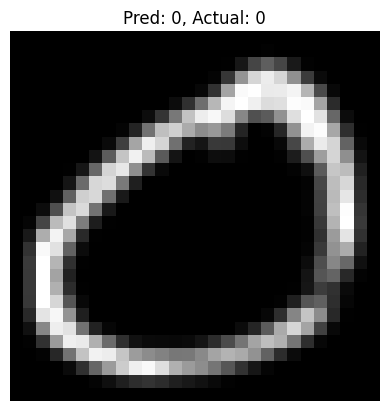

In [16]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow(X_test[i])
    plt.title(f"Pred: {predicted_labels[i]}, Actual: {true_labels[i]}")
    plt.axis("off")
    plt.show()